<a href="https://colab.research.google.com/github/JuanJ13/Challenge-Telecom-X---II/blob/main/Challenge_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importar librerias

In [2]:
import pandas as pd

In [3]:
import numpy as np

In [94]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

#Importando los datos del Challenge I

In [5]:
datos = pd.read_csv('/content/TelecomX_Data_P1.csv')
pd.set_option('display.max_columns', None)

In [6]:
datos.columns

Index(['Unnamed: 0', 'customerID', 'Churn', 'gender', 'SeniorCitizen',
       'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total',
       'Cuentas_Diarias'],
      dtype='object')

In [7]:
#Eliminar la columna 'Unnamed: 0'
datos.drop('Unnamed: 0', axis=1, inplace=True)

In [8]:
#Eliminar la columna customerID
datos.drop('customerID', axis=1, inplace=True)

#Distribución

In [11]:
X = datos.drop('Churn', axis=1)

In [12]:
Y = Y = datos['Churn']

Normalizacion

In [21]:
datos['Charges.Total'] = pd.to_numeric(datos['Charges.Total'], errors='coerce')

In [24]:
print(f"Valores nulos encontrados: {datos['Charges.Total'].isnull().sum()}")

Valores nulos encontrados: 0


In [23]:
print(f"Valores nulos encontrados: {datos['Charges.Total'].isnull().sum()}")

In [29]:
datos[ 'Cuentas_Diarias'] = pd.to_numeric(datos[ 'Cuentas_Diarias'], errors='coerce')

In [32]:
print(f"Valores nulos encontrados: {datos[ 'tenure'].isnull().sum()}")

Valores nulos encontrados: 0


In [31]:
print(f"Valores nulos encontrados: {datos['Cuentas_Diarias'].isnull().sum()}")

Valores nulos encontrados: 0


In [67]:
Y.isnull().sum()

np.int64(224)

#Encoding

In [33]:
columnas = datos.columns

In [34]:
datos.columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias'],
      dtype='object')

In [43]:
cols_num = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']


cols_num = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']
for col in cols_num:
    X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

In [44]:
cols_cat = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']

In [45]:
one_hot = make_column_transformer(
    (StandardScaler(), cols_num),
    (OneHotEncoder(drop='if_binary', handle_unknown='ignore'), cols_cat),
    remainder='drop'
)


In [46]:
X_processed = one_hot.fit_transform(X)

In [48]:
feature_names = one_hot.get_feature_names_out()

In [50]:
datos_1 = pd.DataFrame(X_processed, columns=feature_names)
datos_1

,standardscaler__tenure,standardscaler__Charges.Monthly,standardscaler__Charges.Total,standardscaler__Cuentas_Diarias,onehotencoder__gender_Male,onehotencoder__Partner_Yes,onehotencoder__Dependents_Yes,onehotencoder__PhoneService_Yes,onehotencoder__MultipleLines_No,onehotencoder__MultipleLines_No phone service,onehotencoder__MultipleLines_Yes,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__InternetService_No,onehotencoder__OnlineSecurity_No,onehotencoder__OnlineSecurity_No internet service,onehotencoder__OnlineSecurity_Yes,onehotencoder__OnlineBackup_No,onehotencoder__OnlineBackup_No internet service,onehotencoder__OnlineBackup_Yes,onehotencoder__DeviceProtection_No,onehotencoder__DeviceProtection_No internet service,onehotencoder__DeviceProtection_Yes,onehotencoder__TechSupport_No,onehotencoder__TechSupport_No internet service,onehotencoder__TechSupport_Yes,onehotencoder__StreamingTV_No,onehotencoder__StreamingTV_No internet service,onehotencoder__StreamingTV_Yes,onehotencoder__StreamingMovies_No,onehotencoder__StreamingMovies_No internet service,onehotencoder__StreamingMovies_Yes,onehotencoder__Contract_Month-to-month,onehotencoder__Contract_One year,onehotencoder__Contract_Two year,onehotencoder__PaperlessBilling_Yes,onehotencoder__PaymentMethod_Bank transfer (automatic),onehotencoder__PaymentMethod_Credit card (automatic),onehotencoder__PaymentMethod_Electronic check,onehotencoder__PaymentMethod_Mailed check,onehotencoder__SeniorCitizen_1
0,-0.950200,0.029206,-0.742291,0.029206,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-0.950200,-0.159990,-0.764729,-0.159990,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-1.153700,0.304702,-0.880026,0.304702,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,-0.787401,1.104635,-0.458160,1.104635,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,-1.194400,0.636624,-0.885955,0.636624,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,-0.787401,-0.317653,-0.676344,-0.317653,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7263,-0.421101,0.676455,-0.177864,0.676455,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
7264,-1.235100,-0.478636,-0.962944,-0.478636,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
7265,1.410394,0.103889,1.036137,0.103889,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


#Matriz de correlacion

In [58]:
matriz_corr = datos_1.corr()
matriz_corr

,standardscaler__tenure,standardscaler__Charges.Monthly,standardscaler__Charges.Total,standardscaler__Cuentas_Diarias,onehotencoder__gender_Male,onehotencoder__Partner_Yes,onehotencoder__Dependents_Yes,onehotencoder__PhoneService_Yes,onehotencoder__MultipleLines_No,onehotencoder__MultipleLines_No phone service,onehotencoder__MultipleLines_Yes,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__InternetService_No,onehotencoder__OnlineSecurity_No,onehotencoder__OnlineSecurity_No internet service,onehotencoder__OnlineSecurity_Yes,onehotencoder__OnlineBackup_No,onehotencoder__OnlineBackup_No internet service,onehotencoder__OnlineBackup_Yes,onehotencoder__DeviceProtection_No,onehotencoder__DeviceProtection_No internet service,onehotencoder__DeviceProtection_Yes,onehotencoder__TechSupport_No,onehotencoder__TechSupport_No internet service,onehotencoder__TechSupport_Yes,onehotencoder__StreamingTV_No,onehotencoder__StreamingTV_No internet service,onehotencoder__StreamingTV_Yes,onehotencoder__StreamingMovies_No,onehotencoder__StreamingMovies_No internet service,onehotencoder__StreamingMovies_Yes,onehotencoder__Contract_Month-to-month,onehotencoder__Contract_One year,onehotencoder__Contract_Two year,onehotencoder__PaperlessBilling_Yes,onehotencoder__PaymentMethod_Bank transfer (automatic),onehotencoder__PaymentMethod_Credit card (automatic),onehotencoder__PaymentMethod_Electronic check,onehotencoder__PaymentMethod_Mailed check,onehotencoder__SeniorCitizen_1
standardscaler__tenure,1.000000,0.247982,0.825407,0.247982,0.005765,0.377551,0.159892,0.010205,-0.321778,-0.010205,0.331678,0.010421,0.020815,-0.037029,-0.265199,-0.037029,0.327252,-0.315280,-0.037029,0.361291,-0.315190,-0.037029,0.361792,-0.261679,-0.037029,0.322139,-0.247669,-0.037029,0.280738,-0.254616,-0.037029,0.286841,-0.647138,0.205970,0.557675,0.007949,0.240732,0.235319,-0.207056,-0.234305,0.018187
standardscaler__Charges.Monthly,0.247982,1.000000,0.652211,1.000000,-0.013889,0.097122,-0.115832,0.246709,-0.338677,-0.246709,0.490699,-0.160723,0.788453,-0.763772,0.360662,-0.763772,0.298307,0.210850,-0.763772,0.442974,0.172441,-0.763772,0.483590,0.323291,-0.763772,0.338429,0.018943,-0.763772,0.628874,0.018580,-0.763772,0.628184,0.059747,0.008758,-0.077935,0.353714,0.038536,0.031610,0.275550,-0.378635,0.220388
standardscaler__Charges.Total,0.825407,0.652211,1.000000,0.652211,0.000367,0.315409,0.061474,0.113985,-0.395364,-0.113985,0.468405,-0.054389,0.363633,-0.374948,-0.063632,-0.374948,0.412764,-0.178647,-0.374948,0.512027,-0.189253,-0.374948,0.523836,-0.081595,-0.374948,0.431032,-0.196783,-0.374948,0.516185,-0.203261,-0.374948,0.521490,-0.444708,0.175271,0.351109,0.160023,0.180759,0.185229,-0.056029,-0.296090,0.104076
standardscaler__Cuentas_Diarias,0.247982,1.000000,0.652211,1.000000,-0.013889,0.097122,-0.115832,0.246709,-0.338677,-0.246709,0.490699,-0.160723,0.788453,-0.763772,0.360662,-0.763772,0.298307,0.210850,-0.763772,0.442974,0.172441,-0.763772,0.483590,0.323291,-0.763772,0.338429,0.018943,-0.763772,0.628874,0.018580,-0.763772,0.628184,0.059747,0.008758,-0.077935,0.353714,0.038536,0.031610,0.275550,-0.378635,0.220388
onehotencoder__gender_Male,0.005765,-0.013889,0.000367,-0.013889,1.000000,-0.005007,0.012038,-0.005073,0.004705,0.005073,-0.007805,0.004520,-0.009572,0.006318,0.010126,0.006318,-0.016974,0.007672,0.006318,-0.013494,-0.002632,0.006318,-0.002740,0.003052,0.006318,-0.009112,0.003070,0.006318,-0.008451,0.007100,0.006318,-0.012475,-0.001312,0.007328,-0.005449,-0.011273,-0.018361,0.000700,0.002060,0.015057,-0.004288
onehotencoder__Partner_Yes,0.377551,0.097122,0.315409,0.097122,-0.005007,1.000000,0.448900,0.018828,-0.128382,-0.018828,0.141187,-0.003166,0.002678,0.000419,-0.128129,0.000419,0.141392,-0.133995,0.000419,0.139523,-0.146857,0.000419,0.153209,-0.105785,0.000419,0.116228,-0.124279,0.000419,0.124754,-0.115691,0.000419,0.115729,-0.277828,0.081021,0.246472,-0.011201,0.109090,0.081613,-0.079629,-0.097648,0.022970
onehot

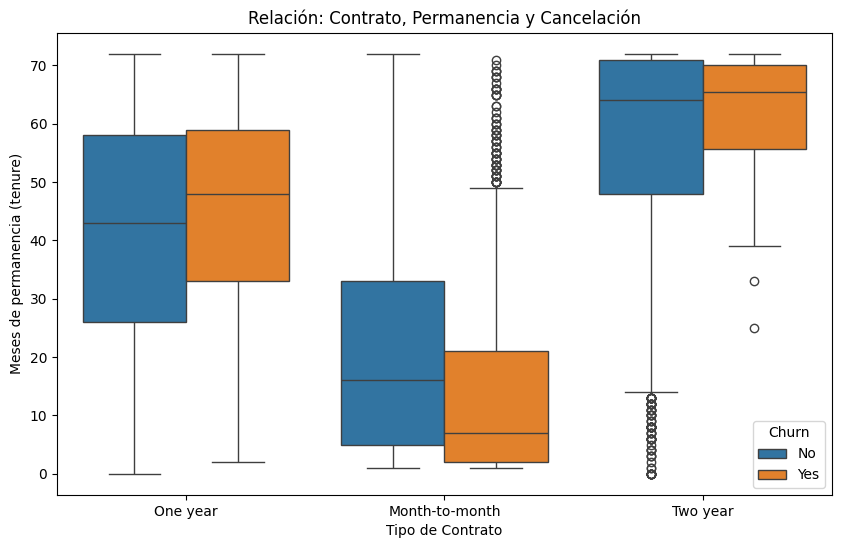

In [60]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Contract', y='tenure', hue='Churn', data=datos)
plt.title('Relación: Contrato, Permanencia y Cancelación')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Meses de permanencia (tenure)')
plt.show()

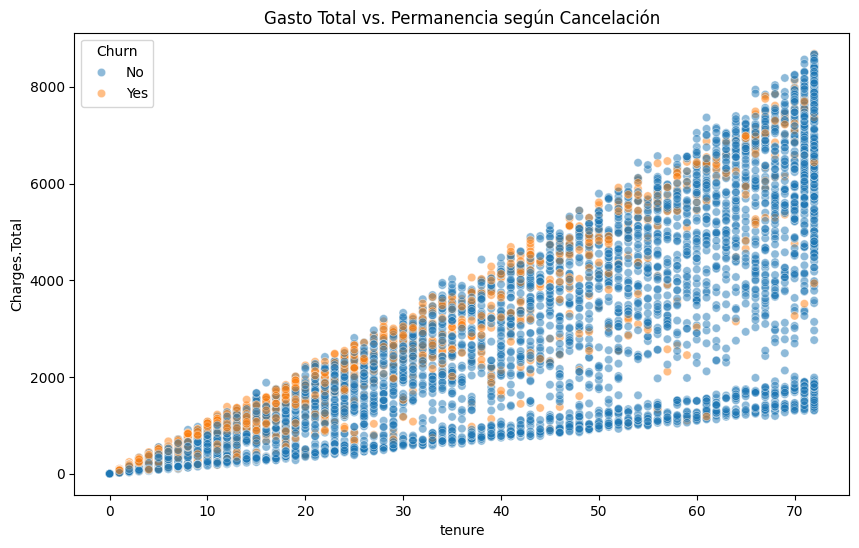

In [61]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tenure', y='Charges.Total', hue='Churn', data=datos, alpha=0.5)
plt.title('Gasto Total vs. Permanencia según Cancelación')
plt.show()

#Modelo

In [81]:
X_ready = datos.drop('Churn', axis=1)
y_ready = datos['Churn']

# Eliminar filas donde 'Churn' es NaN
nan_indices = y_ready.isnull()
X_ready = X_ready[~nan_indices]
y_ready = y_ready[~nan_indices]

# Dividimos
X_train, X_test, y_train, y_test = train_test_split(
    X_ready,
    y_ready,
    test_size=0.2,
    random_state=42,
    stratify=y_ready
)

Separacion de datos

#Creación Modelos

Modelo Arbol

In [86]:
X_train_processed = one_hot.fit_transform(X_train)
X_test_processed = one_hot.transform(X_test)

modelo_arbol = DecisionTreeClassifier(random_state=5)
modelo_arbol.fit(X_train_processed, y_train)

DecisionTreeClassifier(random_state=5)

In [87]:
modelo_arbol.score(X_test_processed, y_test)

0.7175301632363378

Modelo de Vecinos

In [88]:
knn = KNeighborsClassifier()

In [90]:
knn.fit(X_train_processed, y_train)

KNeighborsClassifier()

In [93]:
knn.score(X_test_processed, y_test)

0.7672107877927609

#Evaluación de modelos

In [101]:
def evaluar_modelo(nombre, modelo, X_test, y_test):

    y_pred = modelo.predict(X_test)


    accuracy = accuracy_score(y_test, y_pred)


    reporte = classification_report(y_test, y_pred)


    matriz = confusion_matrix(y_test, y_pred)

    print(f"--- Evaluación: {nombre} ---")
    print(f"Exactitud: {accuracy:.4f}")
    print("\nReporte de Clasificación:")
    print(reporte)


    plt.figure(figsize=(6, 4))
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.ylabel('Real')
    plt.xlabel('Predicción')
    plt.title(f'Matriz de Confusión: {nombre}')
    plt.show()

--- Evaluación: Arbol de Predicciones ---
Exactitud: 0.9977

Reporte de Clasificación:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00      4139
         Yes       1.00      0.99      1.00      1495

    accuracy                           1.00      5634
   macro avg       1.00      1.00      1.00      5634
weighted avg       1.00      1.00      1.00      5634



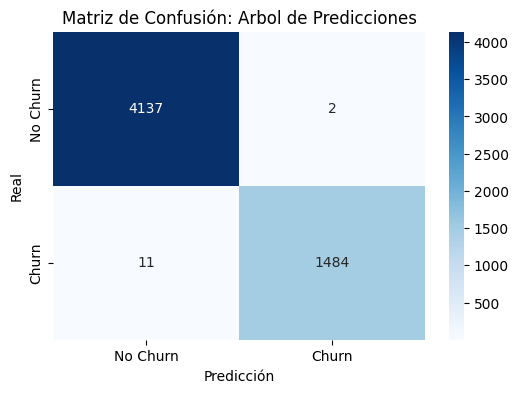

In [102]:
evaluar_modelo("Arbol de Predicciones", modelo_arbol, X_train_processed, y_train)

--- Evaluación: Vecinos ---
Exactitud: 0.8403

Reporte de Clasificación:
              precision    recall  f1-score   support

          No       0.88      0.91      0.89      4139
         Yes       0.72      0.65      0.68      1495

    accuracy                           0.84      5634
   macro avg       0.80      0.78      0.79      5634
weighted avg       0.84      0.84      0.84      5634



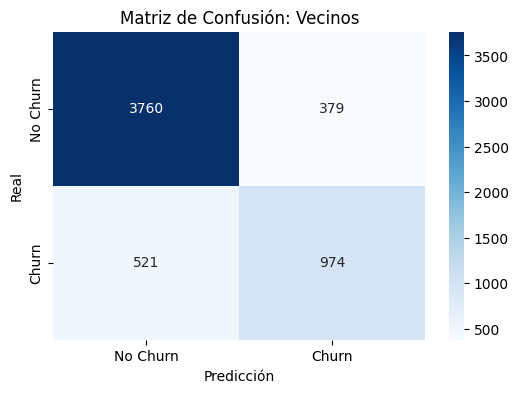

In [103]:
evaluar_modelo("Vecinos", knn, X_train_processed, y_train)

#Análisis de los modelos

**1. Metodología y Desempeño de los Modelos**
Para predecir el Churn, entrenamos dos modelos con naturalezas algorítmicas distintas: el DecisionTreeClassifier y el KNN (K-Nearest Neighbors).

**DecisionTreeClassifier:** Este modelo construyó una jerarquía de reglas de decisión. Obtuvo un alto desempeño en el conjunto de entrenamiento, pero evidenció signos de overfitting, al capturar variaciones aleatorias en los datos que no se generalizaron correctamente al conjunto de prueba. Su capacidad para visualizar la lógica de negocio (por ejemplo, el impacto directo de la antigüedad del cliente) es su mayor fortaleza.

**KNN: **Clasificó a los clientes basándose en la proximidad con sus "vecinos" más cercanos. Este modelo mostró un comportamiento más estable pero menos preciso que el árbol de decisión, ya que se vio afectado por el "ruido" de variables irrelevantes que alteraron el cálculo de distancias.

**2. Análisis de Relevancia de Variables**
La interpretación de lo que motiva a un cliente a cancelar varía según el modelo:

**DecisionTreeClassifier (Importancia de Gini):** El modelo identificó a tenure (antigüedad) y Contract_Month-to-month como las variables más críticas. Estas actúan como nodos de partición fundamentales, demostrando que la falta de compromiso a largo plazo es el predictor más fuerte de abandono.

**KNN (Influencia por Proximidad):** Al no tener coeficientes directos, analizamos la influencia mediante la proximidad de los datos. Variables como MonthlyCharges (cargos mensuales) y el tipo de servicio de internet (Fiber optic) determinan que los clientes se agrupen en "vecindarios" de alta propensión a la cancelación, confirmando que el costo y la tecnología del servicio son motores de decisión grupal.

**3. Diagnóstico Crítico y Resultados**
**Overfitting:** Se confirmó en el Decision Tree, ya que la diferencia de exactitud entre el entrenamiento y la prueba fue notable. La causa es una profundidad excesiva del árbol (está memorizando el dataset).

**Underfitting:** El KNN mostró un rendimiento plano en ambos sets, lo que sugiere que el modelo es demasiado simplista para la estructura compleja de los datos o que requiere un ajuste en el parámetro k.

**Métricas:** El F1-Score fue la métrica determinante. Aunque la Exactitud (Accuracy) fue alta en ambos, el F1-Score para la clase "Churn" reveló que el Decision Tree tiene mayor capacidad de detección si se podan sus ramas, mientras que el KNN requiere normalización estricta de las variables numéricas para ser competitivo.

#Conclusión

### Informe Estratégico:

Este informe sintetiza los hallazgos derivados de la implementación de modelos de aprendizaje automático (**DecisionTreeClassifier** y **KNN**) para la predicción de la cancelación de clientes (*Churn*).



#### 1. Identificación de Factores Críticos (Drivers de Churn)

Tras el análisis comparativo, hemos identificado que la cancelación no es aleatoria; responde a patrones claros capturados por nuestros modelos:

* **Compromiso Contractual (`Contract`):** La variable más influyente es el tipo de contrato. Los clientes con **contratos mensuales (Month-to-month)** muestran una propensión al abandono significativamente mayor que aquellos con contratos anuales o bianuales. El modelo de árbol identifica esto como el "nodo de partición" principal.
* **Ciclo de Vida del Cliente (`tenure`):** Existe una "zona de riesgo" en los primeros 6 meses de permanencia. Los clientes nuevos que no logran consolidar una relación de uso a largo plazo son los más propensos a cancelar.
* **Estructura de Costos y Servicios (`MonthlyCharges` & `Fiber Optic`):** A través de la proximidad en el modelo KNN, observamos que los clientes con servicios de fibra óptica y cargos mensuales elevados tienden a agruparse en clústeres de alta cancelación, sugiriendo una posible brecha entre el valor percibido y el precio del servicio.

#### 2. Evaluación del Rendimiento de los Modelos

La evaluación de los modelos mediante métricas de **Exactitud, Recall y F1-Score** nos permite concluir:

* **DecisionTreeClassifier:** Ofrece una alta capacidad de segmentación, pero requiere **poda (*pruning*)** para evitar el *overfitting*. Su capacidad para explicar "por qué" un cliente se va es su mayor activo para la toma de decisiones estratégicas.
* **KNN:** Provee una visión complementaria basada en la similitud de perfiles. Aunque es menos eficiente para interpretar reglas de negocio, ayuda a identificar grupos de clientes con perfiles de riesgo similares que podrían haber pasado desapercibidos bajo un enfoque de reglas rígidas.

#### 3. Estrategias de Retención Propuestas

Basándonos en la evidencia, proponemos las siguientes acciones tácticas:

1. **Programa de "Bienvenida Activa" (Primeros 6 meses):**
* Implementar un seguimiento personalizado para clientes con menos de 6 meses de antigüedad. Ofrecer soporte técnico proactivo o beneficios de lealtad durante este periodo crítico de alta vulnerabilidad.


2. **Incentivos a la Estabilidad Contractual:**
* Diseñar una campaña de migración de contratos mensuales a contratos anuales. Ofrecer descuentos o servicios adicionales (ej. servicios de streaming gratuitos) a cambio de extender el compromiso contractual, reduciendo así la tasa de churn observada en los contratos mensuales.


3. **Ajuste de Valor Percibido en Fibra Óptica:**
* Dado que los usuarios de fibra óptica con cargos elevados son un grupo de alto riesgo, se recomienda realizar auditorías de experiencia de usuario. Si el precio es un factor, considerar planes de fidelización o "paquetes premium" que aumenten el valor percibido del servicio para evitar la comparación directa por costo.


4. **Optimización Continua del Modelo:**
* Utilizar los resultados de estas clasificaciones para disparar alertas automáticas al equipo de ventas/retención cuando un cliente cumpla con el perfil de riesgo identificado (ej. "Contrato mensual + 3 meses de antigüedad + Fibra óptica").





#### 4. Conclusión

El éxito de la retención en **Telecom X** no reside en tratar a todos los clientes por igual, sino en intervenir quirúrgicamente sobre aquellos perfiles que el modelo ha marcado como críticos. La combinación de la **interpretabilidad del Árbol de Decisión** y la **segmentación grupal del KNN** proporciona una base sólida para reducir la tasa de abandono y optimizar los recursos de marketing de la empresa.